# 03 — Salary Analysis

Salary distribution across job families, seniority levels, and cities.

> **⚠️ Sample Size Warning:** Only ~403 rows (2.1% of the dataset) include salary data. All salary analyses below are based on this small, non-random subset. Postings that disclose salaries may differ systematically from those that do not — for example, roles with transparent pay may skew toward certain industries, seniority levels, or company types. Interpret all salary figures as *indicative* rather than representative of the full German IT market.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family, salary_df

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import box_plot, value_bar, dual_histogram

sdf = salary_df(df)
print(f"Rows with salary data: {len(sdf):,} ({len(sdf)/len(df)*100:.1f}%)")

Rows with salary data: 403 (2.1%)


## Summary Statistics

In [3]:
import pandas as pd

stats = pd.DataFrame({
    "salary_min": sdf["salary_min"].describe(),
    "salary_max": sdf["salary_max"].describe(),
    "salary_mid": sdf["salary_mid"].describe(),
}).T

print(f"Salary summary (n={len(sdf):,} postings with salary data):")
print(f"  Median mid-point: €{sdf['salary_mid'].median():,.0f}")
print(f"  Mean mid-point:   €{sdf['salary_mid'].mean():,.0f}")
print(f"  P25:              €{sdf['salary_mid'].quantile(0.25):,.0f}")
print(f"  P75:              €{sdf['salary_mid'].quantile(0.75):,.0f}")
print(f"  Std deviation:    €{sdf['salary_mid'].std():,.0f}")
print()
stats.round(0)

Salary summary (n=403 postings with salary data):
  Median mid-point: €70,000
  Mean mid-point:   €72,803
  P25:              €57,500
  P75:              €80,091
  Std deviation:    €20,287



,count,mean,std,min,25%,50%,75%,max
salary_min,403.0,60562.0,18067.0,20000.0,47623.0,60000.0,70000.0,124000.0
salary_max,403.0,85043.0,24256.0,32000.0,70000.0,80000.0,98000.0,180000.0
salary_mid,403.0,72803.0,20287.0,26000.0,57500.0,70000.0,80091.0,150000.0


**Takeaway:** The interquartile range gives the most robust sense of typical IT salaries in the dataset. The gap between P25 and P75 reflects the wide spread between junior/entry-level and senior/specialist compensation.

## Salary Distribution

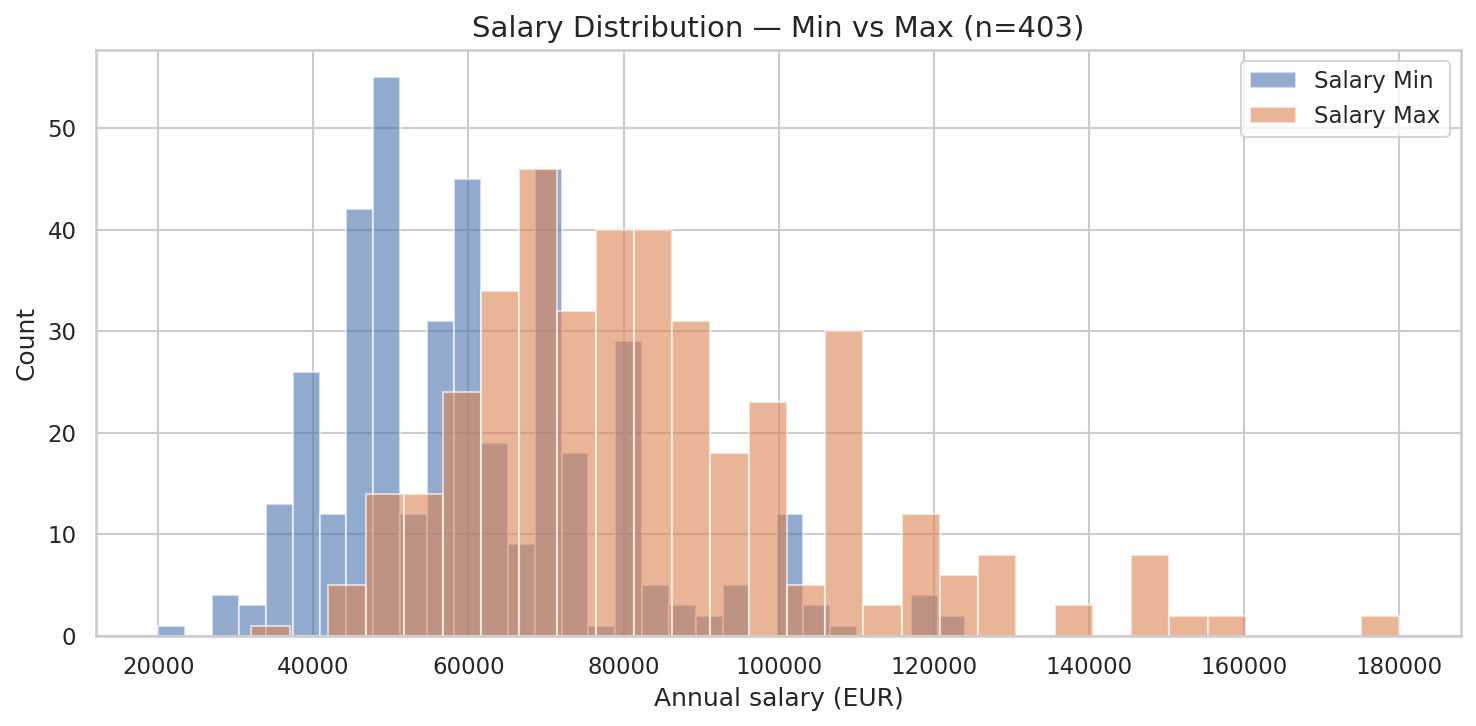

In [4]:
dual_histogram(
    sdf["salary_min"],
    sdf["salary_max"],
    label_a="Salary Min",
    label_b="Salary Max",
    title=f"Salary Distribution — Min vs Max (n={len(sdf):,})",
    xlabel="Annual salary (EUR)",
    bins=30,
    save_as="03_salary_dist.png",
)

**Takeaway:** Both distributions are right-skewed, with the bulk of salaries clustered in a central band and a long tail toward higher compensation. The overlap between min and max histograms is substantial, meaning most postings advertise relatively narrow salary ranges.

## Salary by Job Family

Salary-known postings (excl. Other): 395

Sample size per family:
  Fullstack Developer: n=72
  System Administrator: n=49
  Software Developer: n=43
  DevOps Engineer: n=31
  Backend Developer: n=26
  QA Engineer: n=21
  SAP Consultant: n=19
  Platform Engineer: n=19
  Frontend Developer: n=18
  IT Support / Helpdesk: n=12
  AI Engineer: n=10
  Solution Architect: n=9
  Cloud Engineer: n=6
  Data Scientist: n=5
  IT Security Engineer: n=5
  Business Intelligence Developer: n=5
  Data Engineer: n=5
  IT Consultant: n=4
  Technical Lead: n=4
  Network Engineer: n=4
  ML Engineer: n=4
  Database Administrator: n=3
  Software Architect: n=3
  Business Analyst: n=3
  Site Reliability Engineer: n=3
  Data Analyst: n=3
  Embedded Developer: n=2
  Mobile Developer: n=2
  Product Manager: n=2
  Engineering Manager: n=1
  MLOps Engineer: n=1


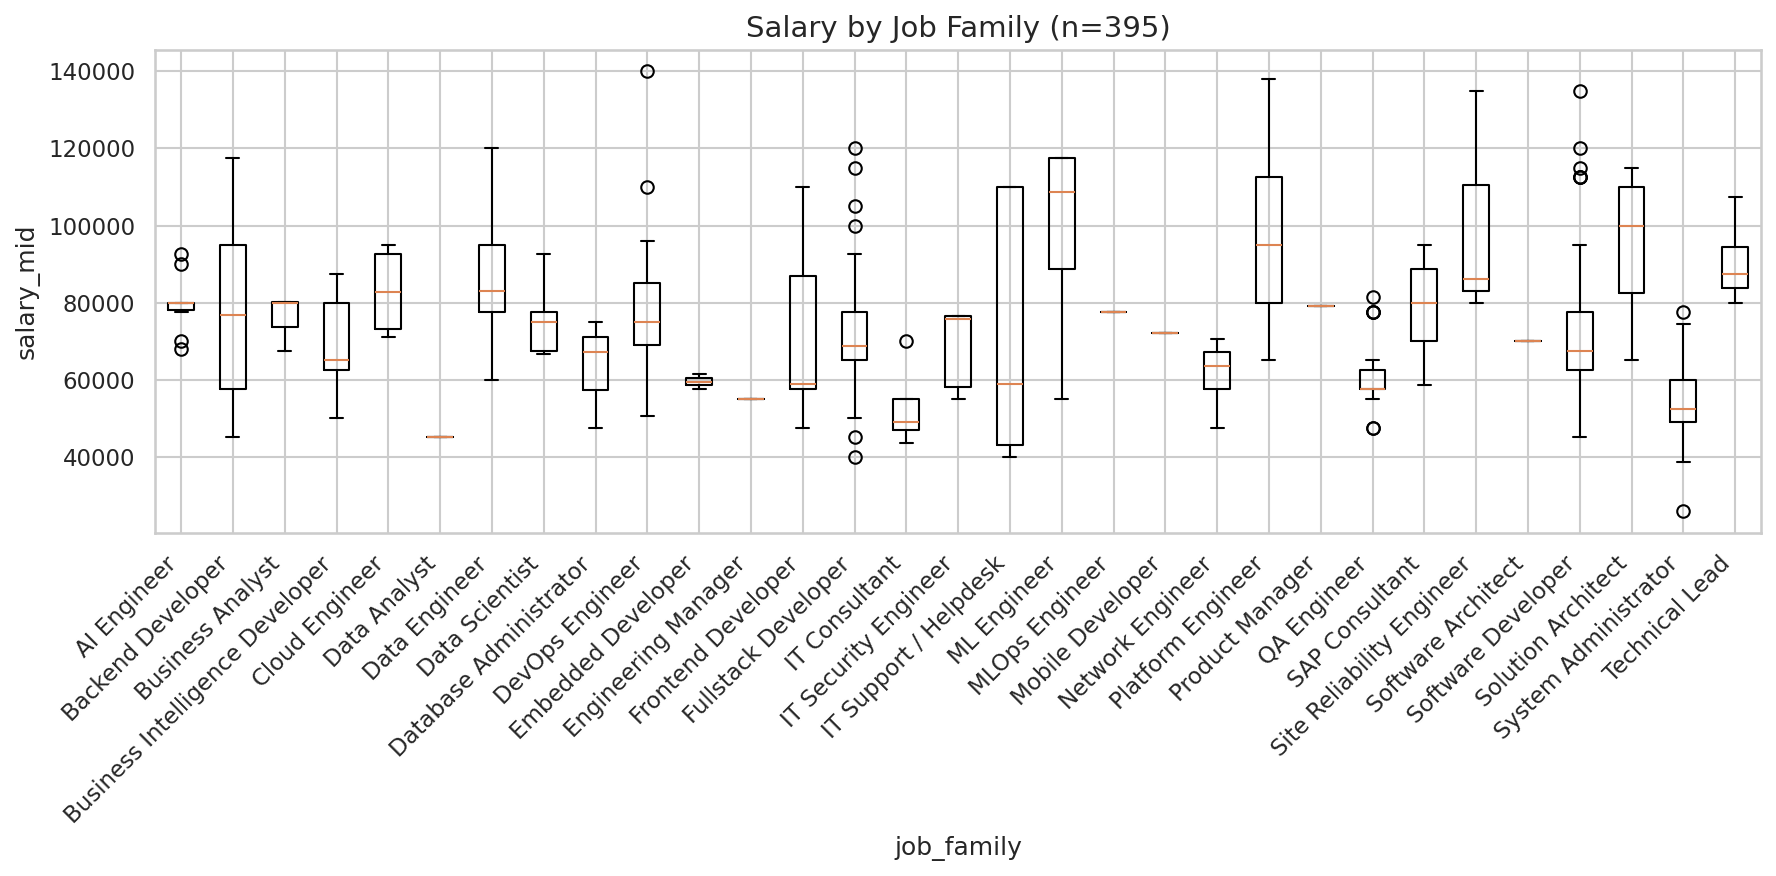

In [5]:
sdf_fam = exclude_other_family(sdf)
n_fam_salary = len(sdf_fam)
# Show sample sizes per family
fam_counts = sdf_fam["job_family"].value_counts()
print(f"Salary-known postings (excl. Other): {n_fam_salary:,}")
print("\nSample size per family:")
for fam, cnt in fam_counts.items():
    print(f"  {fam}: n={cnt}")

box_plot(
    sdf_fam, "job_family", "salary_mid",
    f"Salary by Job Family (n={n_fam_salary:,})",
    save_as="03_salary_family.png",
)

**Takeaway:** Salary ranges vary notably across job families. Families with small sample sizes (n < 10) should be interpreted with caution. The box plot whiskers show that outliers exist in most families, often driven by senior or specialist roles.

## Salary by Seniority

Sample size per seniority level:
  Senior: n=96
  Lead: n=24
  Junior: n=10
  Director: n=1


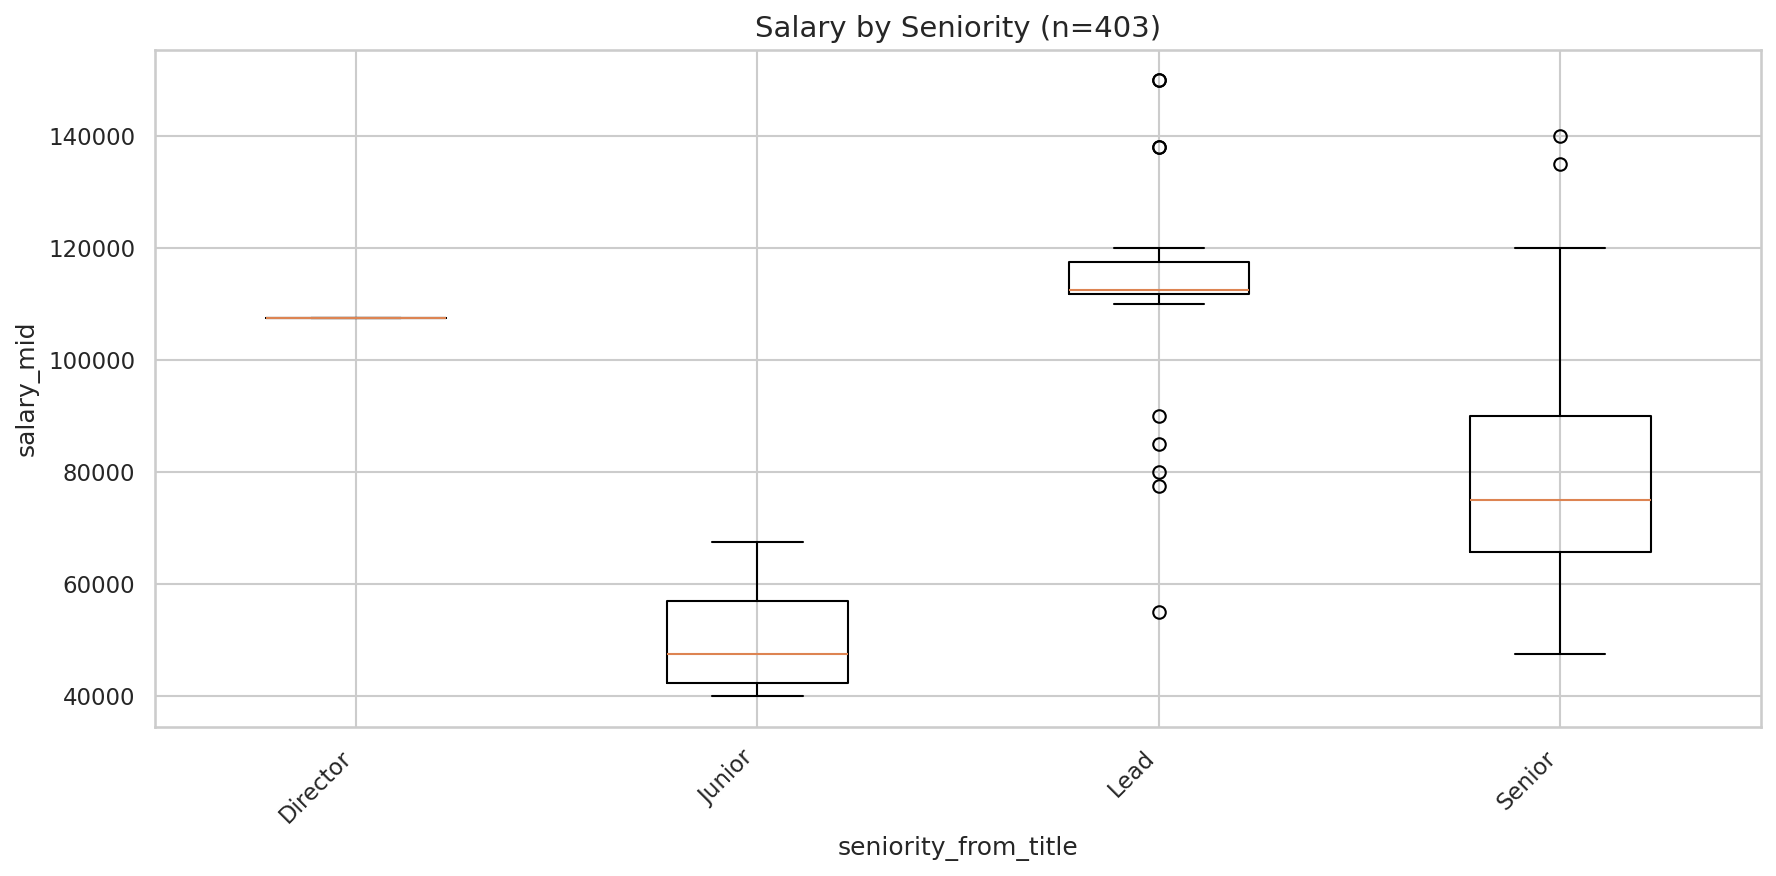

In [6]:
sen_counts = sdf["seniority_from_title"].value_counts()
print("Sample size per seniority level:")
for level, cnt in sen_counts.items():
    print(f"  {level}: n={cnt}")

box_plot(
    sdf, "seniority_from_title", "salary_mid",
    f"Salary by Seniority (n={len(sdf):,})",
    save_as="03_salary_seniority.png",
)

**Takeaway:** As expected, salary scales with seniority. The jump from Mid to Senior is typically the most pronounced, while Lead roles show the widest spread, reflecting varied compensation structures at the management level.

## Salary by City

Sample size per city:
  Nürnberg: n=8
  Leipzig: n=10
  Hamburg: n=21
  Augsburg: n=8
  Köln: n=15
  München: n=27
  Karlsruhe: n=22
  Bremen: n=19
  Frankfurt am Main: n=25
  Berlin: n=74


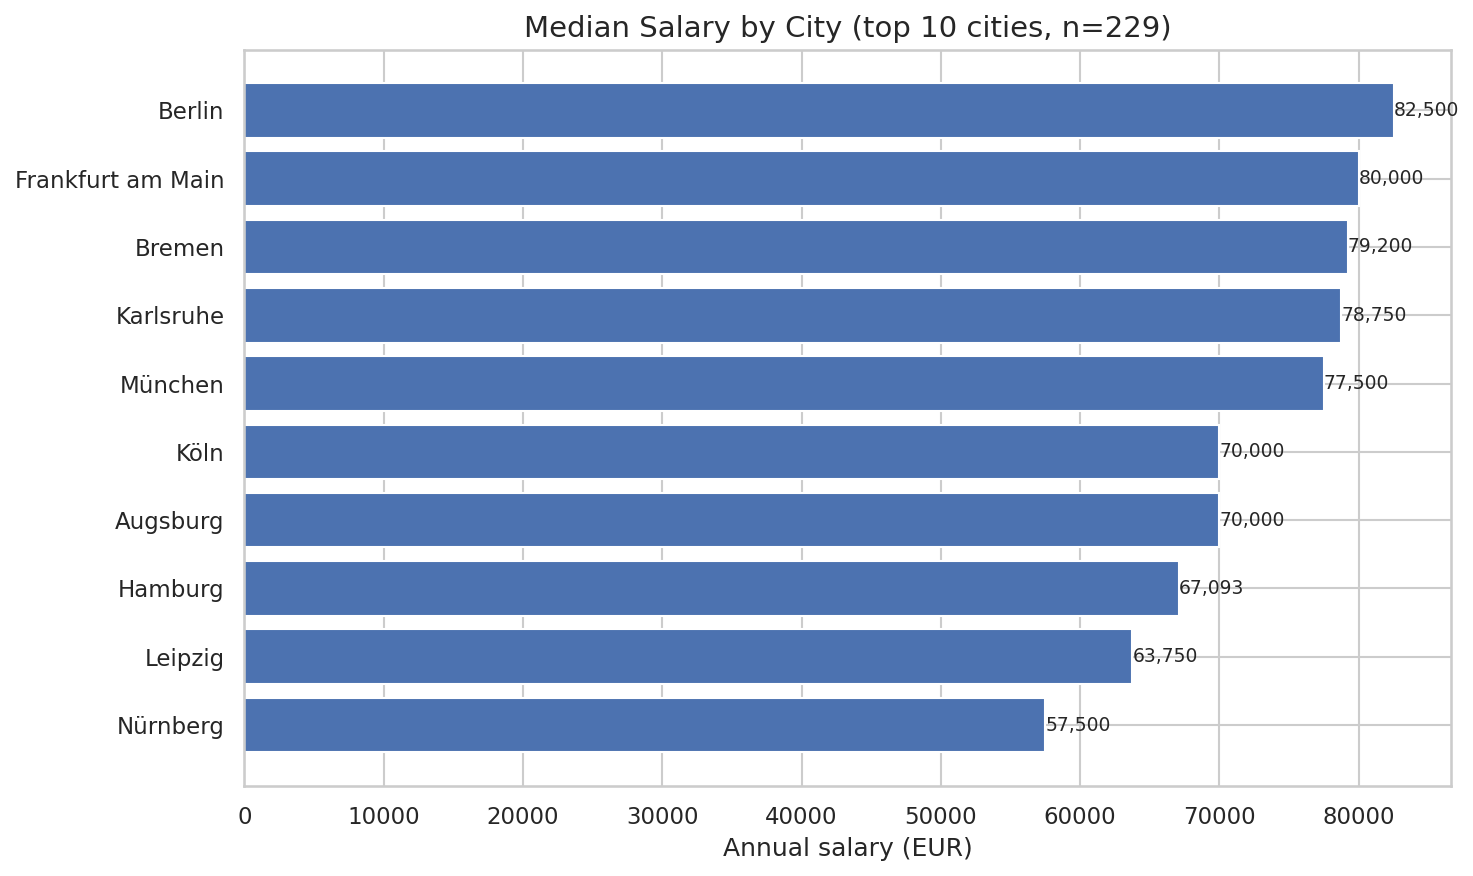

In [7]:
top_cities = sdf[sdf["city"].notna()]["city"].value_counts().head(10).index
sdf_top_cities = sdf[sdf["city"].isin(top_cities)]
city_median = (
    sdf_top_cities
    .groupby("city")["salary_mid"]
    .median()
    .sort_values()
)
# Show sample sizes
city_n = sdf_top_cities["city"].value_counts()
print("Sample size per city:")
for city in city_median.index:
    print(f"  {city}: n={city_n.get(city, 0)}")

value_bar(
    city_median.index,
    city_median.values,
    f"Median Salary by City (top 10 cities, n={len(sdf_top_cities):,})",
    xlabel="Annual salary (EUR)",
    fmt=",.0f",
    save_as="03_salary_city.png",
)

**Takeaway:** Major economic hubs tend to offer higher median salaries, but cost-of-living differences are not captured here. Cities with very few salary-disclosing postings may not be representative. The geographic salary gradient is useful directional guidance for job seekers.

## Experience vs Salary Scatter

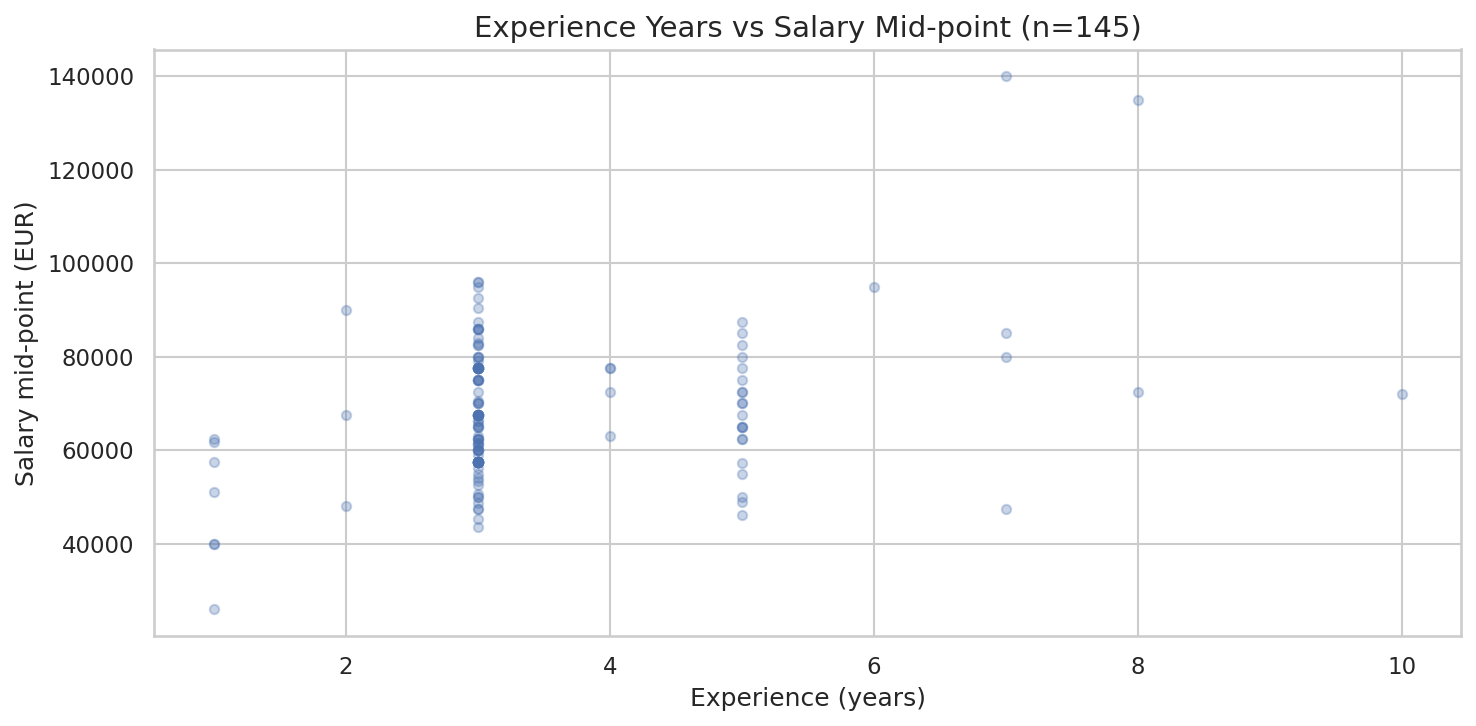

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

exp_salary = sdf[sdf["experience_years"].notna()].copy()
exp_salary["experience_years"] = pd.to_numeric(exp_salary["experience_years"]).astype(int)
n_scatter = len(exp_salary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(exp_salary["experience_years"], exp_salary["salary_mid"], alpha=0.3, s=20)
ax.set_title(f"Experience Years vs Salary Mid-point (n={n_scatter:,})")
ax.set_xlabel("Experience (years)")
ax.set_ylabel("Salary mid-point (EUR)")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "03_exp_salary_scatter.png", dpi=150)
plt.show()
plt.close(fig)

**Takeaway:** There is a general positive relationship between experience and salary, but with considerable variance at every experience level. This scatter suggests that other factors — job family, location, specific skills — play a large role in determining compensation beyond raw years of experience.

## A Note on Selection Bias

Only 2.1% of postings disclose salary ranges. This subset is *not random*: salary-transparent roles may over-represent certain industries (e.g., public sector), company sizes, or geographies. Results here should be treated as a window into salary-transparent postings rather than the full German IT market.